# GW170817: Posterior plot comparison

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import bilby
import pandas as pd
import numpy as np
import seaborn as sns
from bilby.gw.result import CBCResult
import matplotlib.lines as mlines
from kde_contour import kdeplot_2d_clevels

/Users/phurailatpamhemantakumar/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### Waveforms: TaylorF2Ecck, TaylorF2Ecc 3PN, TaylorF2Ecc 3.5PN

In [2]:
rng = np.random.default_rng(12345)

sns.set_theme(palette='colorblind', font_scale=1.5)

def load_mtot_eta_e0(filename, label):
    result = bilby.result.read_in_result(filename)
    chirp_mass = result.posterior["chirp_mass"].values
    mass_ratio = result.posterior["mass_ratio"].values
    e0 = result.posterior["eccentricity"].values
    m1 = (chirp_mass*(1+mass_ratio)**(1/5))/mass_ratio**(3/5)
    m2 = chirp_mass*mass_ratio**(2/5)*(1+mass_ratio)**(1/5)
    mtot = m1 + m2
    eta = (m1*m2)/(mtot**2)
    df = pd.DataFrame(np.transpose(np.array([mtot, eta, e0])), columns=['mtot', 'eta', 'e0'])
    df[""] = label
    return df

result_files = [
    ("../result_files/TF2Ecck_3PN_bayeswave.hdf5", "Ecck 3PN"),
    ("../result_files/TF2Ecc_3PN_bayeswave.hdf5", "Ecc 3PN"),
    ("../result_files/TF2Ecck_3PN_bayeswave_logprior.hdf5", "Ecck 3PN log-prior"),
    ("../result_files/TF2Ecc_3PN_bayeswave_logprior.hdf5", "Ecc 3PN log-prior"),
]

dataframes = [load_mtot_eta_e0(filename, label) for filename, label in result_files]
nsamples = min(len(df) for df in dataframes)
dataframes = [df.sample(nsamples, random_state=rng) for df in dataframes]
result = pd.concat(dataframes, ignore_index=True)
result_solid = result[result[""].isin(["Ecck 3PN", "Ecc 3PN"])].copy()

18:53 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
18:53 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
18:53 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
18:53 bilby INFO    : Global meta data was removed from the result object for compatibility

In [22]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'backend': 'Agg',
    'savefig.dpi': 300,
    'grid.alpha': 0.5,
    'path.simplify': True,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    'mathtext.fontset': 'custom',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 1,
    'ytick.minor.width': 1,
    'lines.markeredgewidth': 1,
    'legend.numpoints': 1,
    'legend.frameon': False,
    'legend.handletextpad': 0.3
})

vars = ['mtot', 'eta', 'e0']
plot_styles = {
    'Ecck 3PN': {'color': 'C0', 'linestyle': '--'},
    'Ecc 3PN': {'color': 'C1', 'linestyle': '--'},
    'Ecck 3PN log-prior': {'color': 'C0', 'linestyle': '-'},
    'Ecc 3PN log-prior': {'color': 'C1', 'linestyle': '-'},
}
palette = {label: style['color'] for label, style in plot_styles.items()}

diag_fill_alpha = 0.15
g = sns.pairplot(
    result_solid,
    vars=vars,
    hue='',
    palette={label: palette[label] for label in result_solid[''].unique()},
    corner=True,
    kind='scatter',
    plot_kws=dict(marker='.', alpha=0.0, s=5),
    diag_kind='kde',
    diag_kws={'alpha': diag_fill_alpha, 'linewidth': 0.8, 'bw_adjust': 1.0},
    height=2.0,
)

for i, var in enumerate(vars):
    ax = g.axes[i, i]
    for label in ['Ecck 3PN log-prior', 'Ecc 3PN log-prior']:
        subset = result[result[''] == label]
        style = plot_styles[label]
        sns.kdeplot(
            data=subset,
            x=var,
            ax=ax,
            color=style['color'],
            linestyle=style['linestyle'],
            linewidth=0.8,
            bw_adjust=1.0,
            fill=False,
            legend=False,
        )

contour_levels = np.sort([0.6827,])
for i, row_var in enumerate(vars):
    for j, col_var in enumerate(vars):
        if i > j:
            ax = g.axes[i, j]
            for label, style in plot_styles.items():
                subset = result[result[''] == label]
                kdeplot_2d_clevels(
                    xs=subset[col_var],
                    ys=subset[row_var],
                    levels=contour_levels,
                    ax=ax,
                    color=style['color'],
                    linestyles=style['linestyle'],
                    linewidths=0.6,
                    # alpha=0.9,
                    auto_bound=False,
                    bw_method=0.3,
                )

if g._legend is not None:
    g._legend.remove()

/Users/phurailatpamhemantakumar/anaconda3/envs/igwn/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/phurailatpamhemantakumar/anaconda3/envs/igwn/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/phurailatpamhemantakumar/anaconda3/envs/igwn/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd

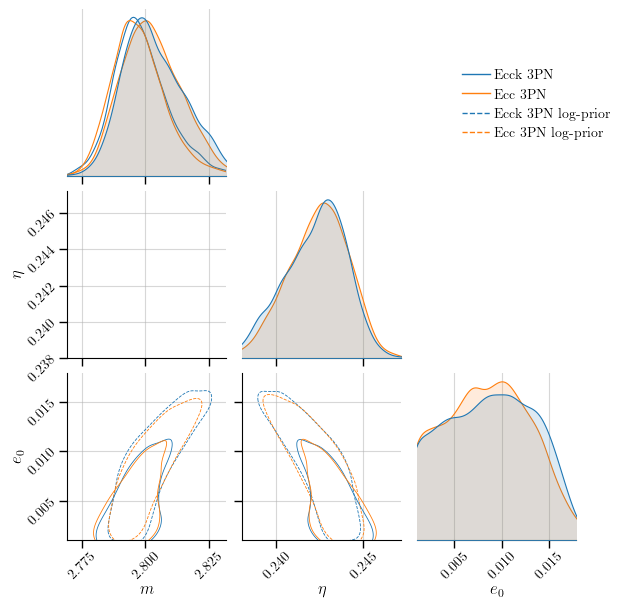

In [23]:
g.axes[2, 2].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 1].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 0].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 0].tick_params(axis='y', rotation=45, pad=1)
g.axes[1, 0].tick_params(axis='y', rotation=45, pad=1)

g.axes[2, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))  

g.axes[2,0].set_xlabel(r'$m$', labelpad=1, fontsize=12)
g.axes[1,0].set_ylabel(r'$\eta$', labelpad=1, fontsize=12)
g.axes[2,1].set_xlabel(r'$\eta$', labelpad=1, fontsize=12)
g.axes[2,0].set_ylabel(r'$e_0$', labelpad=1, fontsize=12)
g.axes[2,2].set_xlabel(r'$e_0$', labelpad=1, fontsize=12)

min_m = 2.769
max_m = 2.832
min_eta = 0.238
max_eta = 0.2472
min_e0 = 0.001
max_e0 = 0.0179
g.axes[2,0].set_xlim(min_m, max_m)
g.axes[2,0].set_ylim(min_e0, max_e0)
g.axes[2,2].set_xlim(min_e0, max_e0)
#
g.axes[2,1].set_xlim(min_eta, max_eta)
g.axes[1,0].set_ylim(min_eta, max_eta)

# add grid
for i in range(3):
    for j in range(3):
        if g.axes[i, j] is not None:
            g.axes[i, j].grid(True, which="both", ls="-", alpha=0.5)

# add legend with line colors
blue_line = mlines.Line2D([], [], color='C0', label='Ecck 3PN', linewidth=1)
orange_line = mlines.Line2D([], [], color='C1', label='Ecc 3PN', linewidth=1)
blue_dashed_line = mlines.Line2D([], [], color='C0', linestyle='--', label='Ecck 3PN log-prior', linewidth=1)
orange_dashed_line = mlines.Line2D([], [], color='C1', linestyle='--', label='Ecc 3PN log-prior', linewidth=1)
handles = [blue_line, orange_line, blue_dashed_line, orange_dashed_line]
labels = [h.get_label() for h in handles] 
g.fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0., 0.9, 0.9, .0), ncol=1) # Adjust loc and ncol as needed

g.savefig("GW170817_mtot_eta_e0_extended.pdf", bbox_inches="tight", dpi=300)
# g.savefig("GW170817_mtot_eta_e0.svg", bbox_inches="tight", dpi=300)
plt.show()

* You don't see the $\eta$ vs $m$ contour because the KDE is too narrow.

* The contour plots of $e_0$ vs $m$ and $e_0$ vs $\eta$ are later crop out using `Affinity Designer` software and create the Figure 5.